# Corpus measures: Spain and Spanish America

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/esTS/blob/master/examples/04_corpus_measures.ipynb)

Two balanced samples of prose from the [corpus of literature](https://sergeyshk.github.io/esTS/datasets/spanishliterature/), one from Spain and one from Spanish America (*America* in the tables), both of about 1900, go through the corpus measures of esTS: keywords against each other and against the frequency dictionary, the dispersion of words over the works, collocations, concordances, Zipf's and Heaps' laws and a comparison of the two sides by every feature of a text. Every section links to the page of the [documentation](https://sergeyshk.github.io/esTS/) with all the statistics and parameters.

## Installation

In Colab the cell installs the library and the spaCy model `es_core_news_sm`, which the comparison of the corpora needs for the morphology; where they are installed it does nothing. The network of collocations is drawn by the executables of [Graphviz](https://graphviz.org/download/), which Colab has.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ests") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyests"], check=True)
if importlib.util.find_spec("es_core_news_sm") is None:
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", "es_core_news_sm", "-q"], check=True
    )

## The two corpora

The [corpus of literature](https://sergeyshk.github.io/esTS/datasets/spanishliterature/) gives the country of every author. The American side is all the prose of the authors from Spanish America. The Philippines of José Rizal are neither Spain nor America, so his two novels are left out. For the Spanish side every Spanish author with prose published from 1885 on gives one work, the one nearest to the median year of the American works; this keeps the number of works, the genre and the period alike.

In [2]:
import re
from collections import Counter
from itertools import accumulate, pairwise
from statistics import median

import matplotlib.pyplot as plt
import pandas as pd
from spacy.lang.es.stop_words import STOP_WORDS

from ests import WordsExtractor
from ests.corpus import collocations, compare_corpora, dispersion, keyness, kwic, print_kwic
from ests.datasets import FreqDict, SpanishLiterature
from ests.diversity_stats import calc_frequency_spectrum, fit_heaps, fit_zipf_mandelbrot
from ests.visualizers import (
    collocation_network,
    dispersion_plot,
    frequency_spectrum_plot,
    heaps_plot,
    keyness_plot,
    zipf,
)

sl = SpanishLiterature()
sl.download()
prose = list(sl.get_records(genre="prose"))

AMERICA = ("Argentina", "Cuba", "México", "Nicaragua", "Perú", "Uruguay")
america = [record for record in prose if record["country"] in AMERICA]
middle = median(record["year_from"] for record in america)

spanish_works = {}
for record in prose:
    if record["country"] == "España" and record["year_from"] >= 1885:
        spanish_works.setdefault(record["author"], []).append(record)
spain = [
    min(author_works, key=lambda record: (abs(record["year_from"] - middle), record["year_from"]))
    for author_works in spanish_works.values()
]
sides = {"America": america, "Spain": spain}

print("Countries of the American works:", sorted({record["country"] for record in america}))
print("Median year of the American works:", middle)
print(
    "Left out:",
    [(record["author"], record["title"]) for record in prose if record["country"] == "Filipinas"],
)

Countries of the American works: ['Argentina', 'Cuba', 'Nicaragua', 'Perú', 'Uruguay']
Median year of the American works: 1906
Left out: [('José Rizal', 'Noli me tángere'), ('José Rizal', 'El filibusterismo')]


Mexico has no prose in the corpus (its only author, Juan Ruiz de Alarcón, wrote plays), so the American side comes from five countries. From every work the first 20,000 words are taken, to the end of a paragraph, so that each work weighs about the same. The lines of a paragraph are joined and runs of spaces collapsed. The old editions put an accent on some monosyllables (`á`, `é`, `ó`, `ú`, `fué`, `fuí`, `dió`, `vió`), which makes `á` and `a` two different words, so the accent is removed, as the page of the corpus advises; the column `old_accents` counts these forms in each sample.

In [3]:
counter = WordsExtractor(filter_nums=True)
OLD_ACCENTS = re.compile(r"\b(?:á|é|ó|ú|fué|fuí|dió|vió)\b", re.IGNORECASE)
UNACCENT = str.maketrans("áéíóúÁÉÍÓÚ", "aeiouAEIOU")


def first_words(text, n=20_000):
    """The paragraphs from the start of a text until they hold n words"""
    paragraphs, total = [], 0
    for paragraph in text.split("\n\n"):
        paragraphs.append(paragraph)
        total += len(counter.extract(paragraph))
        if total >= n:
            break
    return "\n\n".join(paragraphs)


for records in sides.values():
    for record in records:
        text = re.sub(r"[^\S\n]*\n[^\S\n]*", "\n", record["text"])
        text = re.sub(r"(?<!\n)\n(?!\n)", " ", text)
        sample = first_words(re.sub(r"[^\S\n]+", " ", text))
        record["old_accents"] = len(OLD_ACCENTS.findall(sample))
        record["sample"] = OLD_ACCENTS.sub(lambda match: match[0].translate(UNACCENT), sample)
        record["forms"] = counter.extract(record["sample"])

columns = ["author", "title", "year_from", "year_to", "country"]
sample_table = pd.DataFrame(
    [
        {
            "side": side,
            **{key: record[key] for key in columns},
            "words": len(record["forms"]),
            "old_accents": record["old_accents"],
        }
        for side, records in sides.items()
        for record in records
    ]
)
sample_table

,side,author,title,year_from,year_to,country,words,old_accents
0,America,Rubén Darío,Azul...,1888,1888,Nicaragua,20023,33
1,America,Leopoldo Lugones,Las fuerzas extrañas,1906,1906,Argentina,20003,471
2,America,José Martí,Amistad funesta,1885,1885,Cuba,20023,0
3,America,José Martí,La Edad de Oro,1889,1889,Cuba,20146,0
4,America,Ricardo Palma,Tradiciones peruanas,1872,1910,Perú,20046,67
5,America,Roberto J. Payró,El casamiento de Laucha,1906,1906,Argentina,12743,368
6,America,Roberto J. Payró,Pago Chico,1908,1908,Argentina,20002,610
7,America,Roberto J. Payró,Divertidas aventuras del nieto de Juan Moreira,1910,1910,Argentina,20002,629
8,America,Horacio Quiroga,Cuentos de amor de locura y de muerte,1917,1917,Uruguay,20055,57
9,Spain,Vicente Blasco Ibáñez,La maja desnuda,1906,1906,España,20087,475


In [4]:
sample_table.groupby("side", sort=False).agg(
    works=("title", "size"),
    authors=("author", "nunique"),
    words=("words", "sum"),
    first_year=("year_from", "min"),
    last_year=("year_to", "max"),
    old_accents=("old_accents", "sum"),
)

,works,authors,words,first_year,last_year,old_accents
side,,,,,,
America,9,6,173043,1872,1917,2235
Spain,9,9,179491,1893,1906,1912


Each side has nine works: the American one by six authors, of 1872 to 1917 (*Tradiciones peruanas* of Palma is a selection from a series published from 1872 to 1910), the Spanish one by nine authors, of 1893 to 1906, around the median year 1906. The samples hold 173,043 and 179,491 words; only *El casamiento de Laucha* is shorter than the cut, with 12,743 words. The American side is less even by author: three of its works are Payró's and two Martí's, so a word of one writer can reach three American works. The old accents are on both sides, 2235 and 1912 forms, in seven American and five Spanish samples.

## Keywords

[`keyness`](https://sergeyshk.github.io/esTS/corpus/keyness/) finds the words that are significantly more frequent in a target corpus than in a reference one. For each word it gives the log-likelihood $G^2$ with its p-value ([Rayson and Garside](https://ucrel.lancs.ac.uk/llwizard.html)) - whether there is a difference - and [Log Ratio](http://cass.lancs.ac.uk/log-ratio-an-informal-introduction/) - how large it is: one means twice as frequent, and a zero frequency counts as 0.5. The words are the lower-case word forms of [`WordsExtractor`](https://sergeyshk.github.io/esTS/extractors/words/) without numbers, with the stop words kept, so that the pronouns and the verb forms of the address (`vos`, `sos`) stay in the count; a keyword needs at least five occurrences. The tables add the number of works and of authors of its side that use the word and the share of its occurrences written with a capital letter.

In [5]:
for records in sides.values():
    for record in records:
        record["words"] = [form.lower() for form in record["forms"]]
        record["vocabulary"] = set(record["words"])
words = {
    side: [word for record in records for word in record["words"]]
    for side, records in sides.items()
}

totals, capitals = Counter(), Counter()
for records in sides.values():
    for record in records:
        for form in record["forms"]:
            totals[form.lower()] += 1
            capitals[form.lower()] += form[:1].isupper()
capitalized = {word: capitals[word] / total for word, total in totals.items()}


def authors(word, records):
    """Number of the authors whose works use the word"""
    return len({record["author"] for record in records if word in record["vocabulary"]})


def keyword_table(keywords, records):
    """Keywords with the works and the authors of their side and the share of capitals"""
    return pd.DataFrame(
        [
            {
                "word": keyword.word,
                "freq_target": keyword.freq_target,
                "freq_reference": int(keyword.freq_reference),
                "g2": keyword.g2,
                "log_ratio": keyword.log_ratio,
                "works": sum(keyword.word in record["vocabulary"] for record in records),
                "authors": authors(keyword.word, records),
                "capitalized": capitalized[keyword.word],
            }
            for keyword in keywords
        ]
    ).round(2)


america_keys = keyness(words["America"], words["Spain"], min_freq=5)
spain_keys = keyness(words["Spain"], words["America"], min_freq=5)
print("America against Spain")
display(keyword_table(america_keys[:15], america))
print("Spain against America")
display(keyword_table(spain_keys[:15], spain))

America against Spain


,word,freq_target,freq_reference,g2,log_ratio,works,authors,capitalized
0,nébel,109,0,155.13,7.82,1,1,1.00
1,virrey,99,0,140.90,7.68,1,1,0.10
2,meñique,90,0,128.09,7.54,1,1,1.00
3,pago,85,3,98.85,4.88,3,2,0.91
4,lima,59,0,83.97,6.94,2,2,0.98
5,lucía,73,3,82.67,4.66,3,2,0.95
6,carolina,56,0,79.70,6.86,1,1,1.00
7,lidia,54,0,76.85,6.81,2,2,0.98
8,viera,64,2,75.86,5.05,6,4,0.85
9,ana,51,0,72.58,6.73,2,2,1.00


Spain against America


,word,freq_target,freq_reference,g2,log_ratio,works,authors,capitalized
0,rafaela,155,0,209.26,8.22,1,1,1.00
1,avito,131,0,176.86,7.98,1,1,1.00
2,renovales,109,0,147.15,7.72,1,1,1.00
3,silvio,77,0,103.95,7.21,1,1,1.00
4,rosario,104,6,102.37,4.06,6,6,0.93
5,joaquín,71,0,95.85,7.10,2,2,1.00
6,dios,223,59,95.74,1.87,9,9,0.95
7,carrascal,69,0,93.15,7.06,1,1,1.00
8,reynoso,69,0,93.15,7.06,1,1,1.00
9,benina,62,0,83.70,6.90,1,1,1.00


Both lists open with proper names. Nine of the fifteen American keywords are written with a capital in at least 90% of their occurrences (`nébel`, `meñique`, `lucía`, `pago` of *Pago Chico*), and all fifteen Spanish ones in at least 93%; thirteen of the Spanish keywords occur in one or two works. The characters of a novel (`rafaela`, `avito`, `renovales`) are keywords of their side only because the other side has other novels. The rest of the American list mixes a topic of one work (`virrey`, 99 occurrences in one work) with words of several authors: `pesos` (49 against 0, in seven works by four authors), `oro`, `rey`; `misia` (46 against 0) comes from three works of a single author. In the Spanish list `dios` is used by all nine authors, with a capital in 95% of its occurrences, as the name of God.

A second pass leaves out the proper names and the words of a single writer: a word written with a capital in at least 90% of its occurrences is taken for a name (the rule by which the frequency dictionary tells the proper nouns), and a keyword has to be used by at least three authors of its side. [`keyness_plot`](https://sergeyshk.github.io/esTS/visualizers/corpus/#keyness_plot) draws the two lists as diverging bars of $|G^2|$.

In [6]:
def common(keywords, records, min_authors=3):
    """Keywords that are not names and are used by at least min_authors authors"""
    return [
        keyword
        for keyword in keywords
        if capitalized[keyword.word] < 0.9 and authors(keyword.word, records) >= min_authors
    ]


america_common = common(america_keys, america)
spain_common = common(spain_keys, spain)
print("America against Spain")
display(keyword_table(america_common[:15], america))
print("Spain against America")
display(keyword_table(spain_common[:15], spain))

America against Spain


,word,freq_target,freq_reference,g2,log_ratio,works,authors,capitalized
0,viera,64,2,75.86,5.05,6,4,0.85
1,rey,112,21,71.73,2.47,4,4,0.06
2,pesos,49,0,69.74,6.67,7,4,0.02
3,oro,124,28,69.05,2.20,8,5,0.11
4,dijo,243,102,64.62,1.31,9,6,0.01
5,pueblo,123,33,58.62,1.95,8,5,0.00
6,los,2802,2354,57.09,0.30,9,6,0.07
7,pueblos,59,6,52.05,3.35,6,4,0.00
8,como,1368,1073,47.35,0.40,9,6,0.05
9,ciudad,103,30,45.09,1.83,9,6,0.01


Spain against America


,word,freq_target,freq_reference,g2,log_ratio,works,authors,capitalized
0,tú,167,55,55.16,1.55,8,8,0.16
1,artista,68,8,52.04,3.03,7,7,0.00
2,genio,68,9,49.07,2.86,8,8,0.00
3,pintor,54,5,45.77,3.38,4,4,0.00
4,señoras,49,4,43.48,3.56,6,6,0.02
5,usted,271,134,42.39,0.96,7,7,0.08
6,os,61,10,38.86,2.56,5,5,0.25
7,estudio,43,4,36.38,3.37,5,5,0.00
8,qué,575,375,35.42,0.56,9,9,0.32
9,tío,82,22,34.69,1.85,4,4,0.01


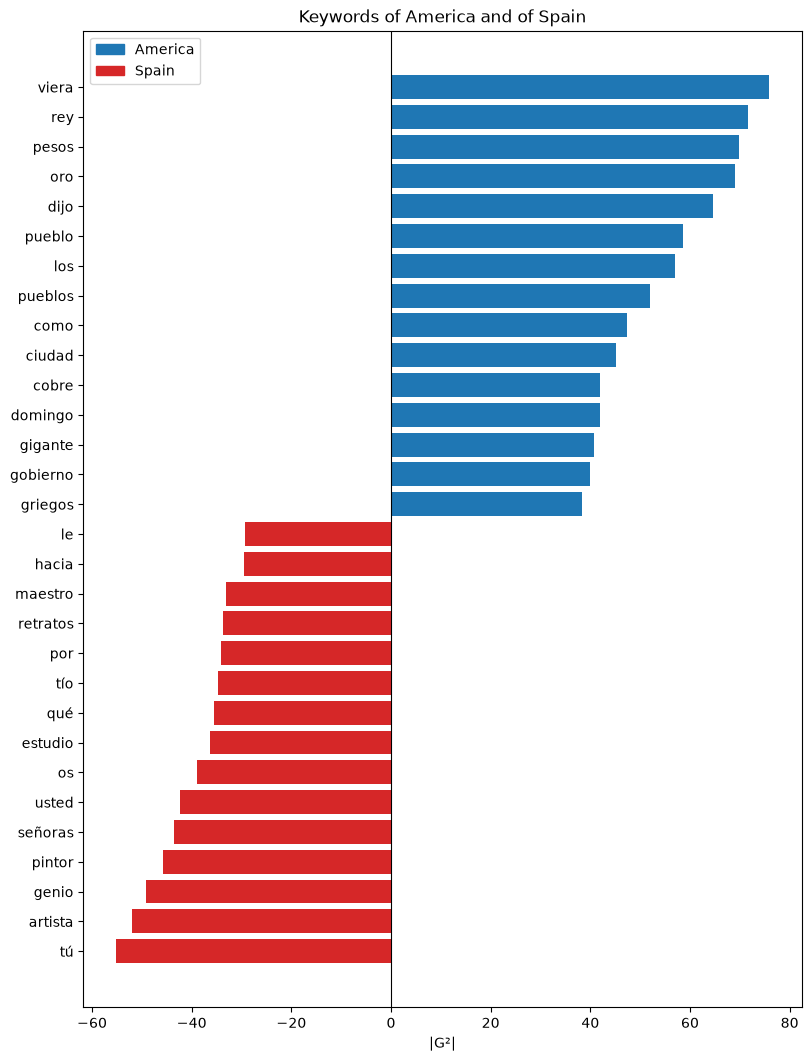

In [7]:
keyness_plot(
    america_common,
    spain_common,
    top_n=15,
    labels={
        "title": "Keywords of America and of Spain",
        "xlabel": "|G²|",
        "target": "America",
        "reference": "Spain",
    },
)
plt.show()

The American list still starts with `viera`, which is written with a capital in 85% of its occurrences: mostly a name just under the threshold, not the verb. Then come words of the themes of the works, used by three to six authors - `rey`, `oro`, `pueblo` and `pueblos`, `ciudad`, `gobierno`, `griegos` - with `pesos`, and `dijo` (243 against 102, Log Ratio 1.31), which all nine American works use. The Spanish list is led by the address, `tú` (167 against 55), `usted` and `os`, and has words of art - `artista`, `genio`, `pintor`, `retratos` - in four to eight Spanish works, a theme of the chosen novels rather than a variety of the language. The grammatical words show why $G^2$ and Log Ratio are read together: `los` (2802 against 2354) and `por` (1860 against 1463) reach a $G^2$ of 57.09 and 34.13 with a Log Ratio of only 0.30 and 0.29, about 1.2 times as frequent, certain only because the words are so frequent. `le` is more frequent in Spain (Log Ratio 0.35), as the leísmo of Spain would make it, but the forms alone cannot show its function. On the chart the American bars are the longer ones: $|G^2|$ up to 75.86 (`viera`) against 55.16 (`tú`).

The forms of the address, the words of money and a few others can be looked up in the full lists; here $G^2$ and Log Ratio are signed from the American side, negative when the word is more frequent in Spain. A second table counts the forms of the address in every work.

In [8]:
signed = {
    keyword.word: keyword
    for positive in (True, False)
    for keyword in keyness(words["America"], words["Spain"], positive=positive)
}
watch = [
    "vos",
    "sos",
    "tú",
    "vosotros",
    "os",
    "usted",
    "usté",
    "ustedes",
    "plata",
    "pesos",
    "dinero",
    "misia",
    "comisario",
    "quizá",
    "acaso",
]
pd.DataFrame(
    [
        {
            "word": word,
            "America": signed[word].freq_target,
            "Spain": int(signed[word].freq_reference),
            "works_America": sum(word in record["vocabulary"] for record in america),
            "works_Spain": sum(word in record["vocabulary"] for record in spain),
            "g2": signed[word].g2,
            "log_ratio": signed[word].log_ratio,
        }
        for word in watch
    ]
).round(2)

,word,America,Spain,works_America,works_Spain,g2,log_ratio
0,vos,17,31,4,5,-3.65,-0.81
1,sos,10,0,3,0,14.23,4.37
2,tú,55,167,6,8,-55.16,-1.55
3,vosotros,9,4,2,3,2.16,1.22
4,os,10,61,3,5,-38.86,-2.56
5,usted,134,271,9,7,-42.39,-0.96
6,usté,26,6,2,1,14.22,2.17
7,ustedes,22,12,7,3,3.36,0.93
8,plata,64,16,8,5,32.62,2.05
9,pesos,49,0,7,0,69.74,6.67


In [9]:
address = ["vos", "sos", "tú", "vosotros", "os", "ustedes", "usté"]
pd.DataFrame(
    [
        {"side": side, "title": record["title"]}
        | {word: record["words"].count(word) for word in address}
        for side, records in sides.items()
        for record in records
    ]
)

,side,title,vos,sos,tú,vosotros,os,ustedes,usté
0,America,Azul...,2,0,13,8,7,0,0
1,America,Las fuerzas extrañas,0,0,1,0,1,8,0
2,America,Amistad funesta,0,0,8,0,0,5,0
3,America,La Edad de Oro,0,0,20,0,0,0,0
4,America,Tradiciones peruanas,1,0,0,1,2,2,0
5,America,El casamiento de Laucha,4,5,0,0,0,3,15
6,America,Pago Chico,10,2,0,0,0,2,11
7,America,Divertidas aventuras del nieto de Juan Moreira,0,3,3,0,0,1,0
8,America,Cuentos de amor de locura y de muerte,0,0,10,0,0,1,0
9,Spain,La maja desnuda,0,0,3,0,0,0,0


The voseo is weak in the counts: `vos` is not an American keyword at all, 17 occurrences against 31 in Spain ($G^2$ −3.65, below the critical 3.84), while the verb form `sos` (10 against 0, $G^2$ 14.23) and the colloquial `usté` (26 against 6, $G^2$ 14.22) are. The table by work shows where the forms are: `sos` only in the three works of Payró, whose two works with `vos` have no `tú`; `usté` in Payró (15 and 11) and in Pereda (6); 24 of the 31 Spanish `vos` and 51 of the 61 Spanish `os` in *Sonata de primavera*. `tú` is spread over eight Spanish works (167 against 55), while `vosotros` and `ustedes` differ too little to be significant ($G^2$ 2.16 and 3.36). Money is the clearest lexical difference: `plata` (64 against 16) and `pesos` (49 against 0) in America, `dinero` (56 against 22) in Spain. `misia` and `comisario` occur on the American side only, in three works each, and `quizá` (27 against 2) and `acaso` (58 against 14) split the two sides like a pair of synonyms.

### Against the frequency dictionary

The reference may also be the [frequency dictionary](https://sergeyshk.github.io/esTS/datasets/freqdict/) `FreqDict` of the Spanish books of Google Books Ngram of 1980-2019, 63 billion words. The target is then word forms with the stop words kept, and both sides go to the keys of the dictionary by `lemma_key`, so the keywords are lemmas, some with the label of another lemma.

In [10]:
fd = FreqDict()
fd.download()
dictionary_keys = {side: keyness(words[side], fd, min_freq=5, top_n=50) for side in sides}
columns = ["word", "freq_target", "ipm_target", "ipm_reference", "g2", "log_ratio"]
pd.DataFrame(dictionary_keys["America"][:15])[columns].round(2)

,word,freq_target,ipm_target,ipm_reference,g2,log_ratio
0,nébel,109,630.79,0.10,1687.57,12.62
1,yo,1839,10642.48,4313.64,1134.27,1.30
2,meñique,90,520.84,1.25,906.14,8.70
3,mi,727,4207.22,1473.36,580.81,1.51
4,tatita,42,243.06,0.12,555.35,10.98
5,don,361,2089.14,444.22,549.31,2.23
6,misia,46,266.21,0.41,503.84,9.34
7,suncho,37,214.12,0.10,493.33,11.06
8,kassim,34,196.76,0.10,447.60,10.94
9,virrey,107,619.22,30.47,441.03,4.34


In [11]:
top = {side: [keyword.word for keyword in keywords] for side, keywords in dictionary_keys.items()}
print("In both top 50:", ", ".join(word for word in top["America"] if word in top["Spain"]))
print("America only:", ", ".join(word for word in top["America"] if word not in top["Spain"]))
print("Spain only:", ", ".join(word for word in top["Spain"] if word not in top["America"]))
negative = keyness(words["America"], fd, positive=False, top_n=10)
print("Negative keywords of America:", ", ".join(keyword.word for keyword in negative))

In both top 50: yo, mi, don, aquel, ojo, oh, y, no, querer, su, alma, qué, él
America only: nébel, meñique, tatita, misia, suncho, kassim, virrey, ver, lidia, decir, lucir, ir, sol, carolina, aquiles, ferreiro, keleffy, vezzera, oro, echar, ah, andar, como, barrar, suzette, andrea, noche, gertrudis, mirar, uno, sátiro, gigante, mano, berta, garcín, salir, azul
Spain only: avito, rafaela, renoval, tú, benina, carrascal, arturito, reynoso, belerofonte, tristán, silvio, casandra, miniar, chiscar, apolodorar, princesa, rosario, gaetani, fulgenciar, pinín, quimera, elena, genio, polonio, espolique, figueredo, señora, pobre, leoncia, tío, arial, almudena, yobates, paca, pintar, exclamar, joaquín
Negative keywords of America: de, del, social, económico, nacional, el, tipo, este, p, sistema


Against the books of the dictionary both sides get the register of fiction: the first person `yo` (10,642.48 ipm in the American sample against 4313.64 in the dictionary) and `mi`, `don`, `aquel`, `ojo`, the interjection `oh` are in the top 50 of both, and the negative keywords of America are the words of scholarly prose that the page of `keyness` predicts: `de`, `del`, `social`, `económico`, `nacional`, `sistema`. The keywords of one side only are again mostly names, with `misia` and `tatita` on the American side and `tú`, `señora`, `tío` on the Spanish one. Some carry the label of another lemma, as the same page warns: `renoval` is the name `renovales` of the table above, read as a plural.

## Dispersion

A keyword may come from one work. [`dispersion`](https://sergeyshk.github.io/esTS/corpus/dispersion/) measures how evenly a word is spread over the parts of a corpus, here the nine American works with their sizes. The main measure is DP, the deviation of proportions of [Gries (2008)](https://www.stgries.info/research/2008_STG_Dispersion_IJCL.pdf): 0 - the word follows the sizes of the parts, values near one - it is gathered in one of them; Juilland's D reads the other way, 1 - even. [`dispersion_plot`](https://sergeyshk.github.io/esTS/visualizers/corpus/#dispersion_plot) marks every occurrence in the joined American works.

In [12]:
sizes = [len(record["words"]) for record in america]
targets = ["dijo", "plata", "pueblo", "ustedes", "pesos", "vos", "misia", "sos", "comisario"]
spread = pd.DataFrame(
    [row for word in targets for row in dispersion(words["America"], parts=sizes, word=word)]
)
spread[["word", "freq", "dp", "dp_norm", "juilland_d", "carroll_d2"]].round(2)

,word,freq,dp,dp_norm,juilland_d,carroll_d2
0,dijo,243,0.28,0.30,0.72,0.89
1,plata,64,0.32,0.35,0.73,0.85
2,pueblo,123,0.41,0.44,0.67,0.78
3,ustedes,22,0.42,0.46,0.66,0.77
4,pesos,49,0.55,0.60,0.51,0.63
5,vos,17,0.64,0.69,0.44,0.50
6,misia,46,0.70,0.75,0.49,0.49
7,sos,10,0.70,0.75,0.38,0.42
8,comisario,27,0.77,0.84,0.34,0.35


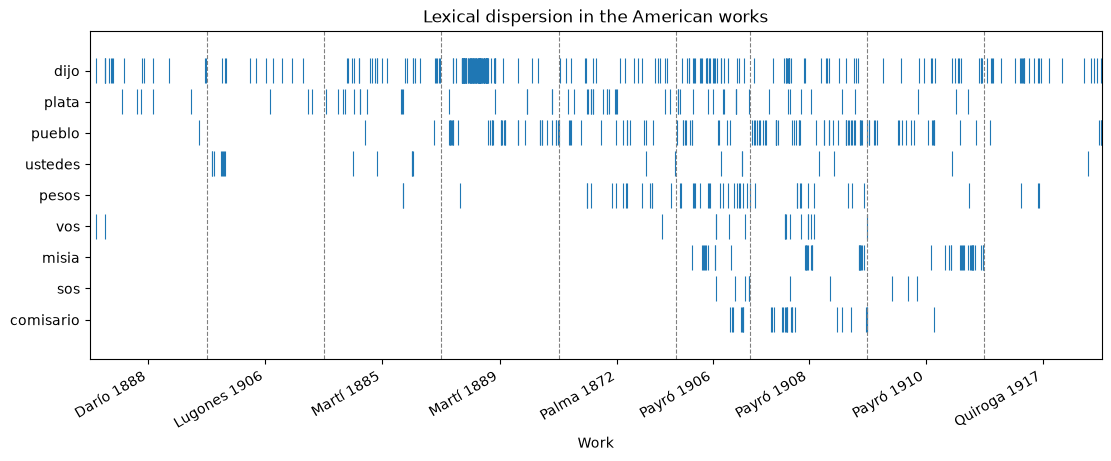

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
dispersion_plot(
    words["America"],
    targets,
    ax=ax,
    labels={"title": "Lexical dispersion in the American works", "xlabel": "Work"},
)
bounds = [0, *accumulate(sizes)]
for bound in bounds[1:-1]:
    ax.axvline(bound, color="gray", linewidth=0.8, linestyle="--")
ax.set_xticks(
    [(start + end) / 2 for start, end in pairwise(bounds)],
    labels=[f"{record['author'].split()[-1]} {record['year_from']}" for record in america],
    rotation=30,
    ha="right",
)
plt.show()

`dijo` is the most even word of the list (DP 0.28, Juilland's D 0.72) and occurs in every work, densest in *La Edad de Oro* of Martí (1889). `plata` (DP 0.32) is in every work but Quiroga's; `pueblo` (0.41) is dense in Martí 1889 and in Payró, `ustedes` (0.42) in Lugones, and `pesos` (0.55) mostly in Palma and Payró. The words of regional speech are gathered: `misia`, `sos` and `comisario` (DP 0.70, 0.70 and 0.77) occur only in the three works of Payró, and `vos` (0.64) is sparse and mostly his too. Their keyness in the previous section is the keyness of one author: a keyword with a high DP describes a writer as much as a variety of Spanish.

## Collocations

[`collocations`](https://sergeyshk.github.io/esTS/corpus/collocations/) finds the pairs of words that occur together more often than chance would give. The words are lemmas without the stop words of spaCy, the window is five words, a pair has to occur at least twice, and the measure is [logDice](https://www.sketchengine.eu/glossary/logdice/) (at most 14; with a window of five a pair always side by side gets about 11.7). The node is the lemma `peso` in both corpora, and [`collocation_network`](https://sergeyshk.github.io/esTS/visualizers/corpus/#collocation_network) draws the American pairs.

In [14]:
lemmatizer = WordsExtractor(
    use_lexemes=True, lowercase=True, filter_nums=True, stopwords=STOP_WORDS
)
lemmas = {
    side: [lemma for record in records for lemma in lemmatizer.extract(record["sample"])]
    for side, records in sides.items()
}
peso = {
    side: collocations(side_lemmas, window=5, node="peso", min_freq=2)
    for side, side_lemmas in lemmas.items()
}
for side, found in peso.items():
    print(f"{side}: peso {lemmas[side].count('peso')} times, {len(found)} collocations")
    display(pd.DataFrame(found[:12]).round(2))

America: peso 66 times, 81 collocations


,left,right,freq_left,freq_right,freq_pair,score
0,mil,peso,49,66,14,9.64
1,peso,cobrar,66,8,4,8.47
2,peso,cajón,66,11,4,8.41
3,pagar,peso,36,66,5,8.33
4,millón,peso,14,66,3,7.94
5,quince,peso,26,66,3,7.74
6,aires,peso,29,66,3,7.69
7,peso,ganar,66,31,3,7.66
8,sacar,peso,69,66,4,7.60
9,peso,regañar,66,2,2,7.59


Spain: peso 12 times, 3 collocations


,left,right,freq_left,freq_right,freq_pair,score
0,peso,densidad,12,2,2,9.87
1,peso,quitar,12,43,2,7.90
2,peso,mirar,12,186,2,6.05


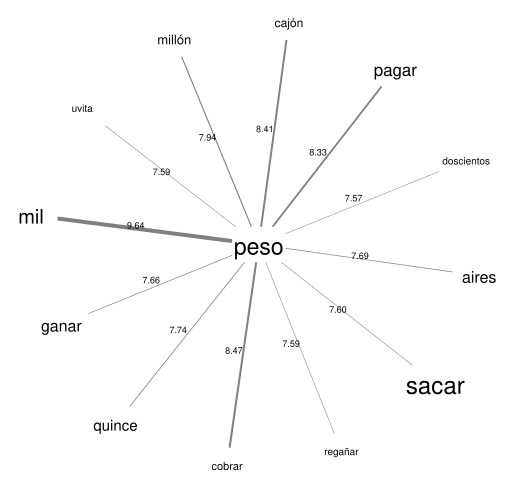

In [15]:
collocation_network(peso["America"], top_n=12)

In America `peso` occurs 66 times and has 81 collocates of at least two co-occurrences; the strongest are numbers and verbs of money: `mil` (14 co-occurrences, logDice 9.64), `millón`, `quince`, `doscientos`, `pagar`, `cobrar`, `ganar`, `sacar`. This `peso` is the currency. In Spain the lemma occurs 12 times with three collocates - `densidad`, `quitar`, `mirar` - none of them a number or a verb of paying, and `densidad` points to weight. The network draws the twelve American pairs as a star around the node, the width of an edge by logDice.

## Concordance

`plata` is a keyword of America, used by five of its six authors, but a list cannot tell the metal from the money. A KWIC concordance of [`kwic`](https://sergeyshk.github.io/esTS/corpus/kwic/) shows every occurrence in its context, aligned by [`print_kwic`](https://sergeyshk.github.io/esTS/corpus/kwic/). The search goes by lemma (`by_lemma=True`), so `platas` would be found too; a second, case-sensitive search (`ignore_case=False`) counts `Plata` with a capital.

In [16]:
pd.DataFrame(
    [
        {
            "side": side,
            "author": record["author"],
            "title": record["title"],
            "plata": len(kwic(record["sample"], "plata", by_lemma=True)),
            "Plata": len(kwic(record["sample"], "Plata", ignore_case=False)),
        }
        for side, records in sides.items()
        for record in records
    ]
).query("plata > 0")

,side,author,title,plata,Plata
0,America,Rubén Darío,Azul...,5,0
1,America,Leopoldo Lugones,Las fuerzas extrañas,3,0
2,America,José Martí,Amistad funesta,11,0
3,America,José Martí,La Edad de Oro,6,1
4,America,Ricardo Palma,Tradiciones peruanas,17,0
5,America,Roberto J. Payró,El casamiento de Laucha,12,0
6,America,Roberto J. Payró,Pago Chico,7,4
7,America,Roberto J. Payró,Divertidas aventuras del nieto de Juan Moreira,3,0
11,Spain,Benito Pérez Galdós,Misericordia,2,0
12,Spain,Armando Palacio Valdés,Tristán o el pesimismo,3,0


In [17]:
laucha = next(record for record in america if record["title"] == "El casamiento de Laucha")
print_kwic(kwic(laucha["sample"], "plata", by_lemma=True, window=6), width=40)

          con hambre, todos los días sin  plata  ,--comencé por fin a temar con
    centavo--¡yo que nunca había juntado  plata  !--hasta que reuní todo lo que
                   a ir sin boleto y sin  plata  . Lo peor es que para ese
              con usted, no digo por esa  plata  ... hasta por mucho menos... Estoy cansa
                  ella,--y yo le daré la  plata  , para que se vaya a Chivilcoy
   decía anquel) y estamos ganando mucha  plata  . Y... ¿quiere que le diga? Lo
                   y como lo que era por  plata  no había que echarse atrás, porque
         Parecía que se quería tragar la  plata  ! Cuando le di los ciento cincuenta
argarla, pobrecita!... Quiso esconder la  plata  , pero, ¡por donde no la iba
              un rincón. --¡No es por la  plata  ! ¡no es por la plata! ¡Es
                 la plata! ¡no es por la  plata  ! ¡Es que veo que no me
          me debés la vida? Devolvéme mi  plata  , ¡birbante, canaglia! Y yo, ¿cómo iba


In [18]:
for record in america:
    lines = kwic(record["sample"], "plata", by_lemma=True, window=6)[:2]
    if lines and record["title"] != "El casamiento de Laucha":
        print(f"{record['title']} ({record['author']})")
        print_kwic(lines, width=40)

Azul... (Rubén Darío)
        sí. --Hijo, al trabajo, a buscar  plata  ; hoy es sábado. Y se fue
      del mundo, disfrazado de papel, de  plata  , de cobre y hasta de plomo
Las fuerzas extrañas (Leopoldo Lugones)
            se transformó en un casco de  plata  , dando origen al sobrenombre del caball
    brillaba como una monstruosa bola de  plata  . La atmósfera era de fósforo con


Amistad funesta (José Martí)
   flores desatadas sobre una bandeja de  plata  con dibujos de oro. Sus amigas
    fuertes, y otras sutiles lindezas en  plata  y en oro, no halla empleo
La Edad de Oro (José Martí)
               San Martín, del Río de la  Plata  ; Hidalgo, de México. Se les deben
               sacó la espada de puño de  plata  para matarlo delante de los reyes


Tradiciones peruanas (Ricardo Palma)
         aclarado de azur; el segundo en  plata  , con león rampante de gules y
        este último una gruesa cadena de  plata  con hermosísimos sellos. Si añadimos que


Pago Chico (Roberto J. Payró)
       miércoles se le ocurre robarse la  plata  de la municipalidad, a mí me
             de fiesta el viajecito a La  Plata  entre dos vigilantes, y quizá con
Divertidas aventuras del nieto de Juan Moreira (Roberto J. Payró)
    sordo ruido, mientras la bombilla de  plata  saltaba repicando con notas argentinas. 
       su tapete verde, su campanilla de  plata  y el amenazante bombo de las


In [19]:
for record in spain:
    lines = kwic(record["sample"], "plata", by_lemma=True, window=6)
    if lines:
        print(f"{record['title']} ({record['author']})")
        print_kwic(lines, width=40)

Misericordia (Benito Pérez Galdós)
                   Dios hizo el oro y la  plata  ... Los billetes, no sé... Pero también
           había en la casa cubiertos de  plata  , ni objeto alguno de metal valioso
Tristán o el pesimismo (Armando Palacio Valdés)
     picatostes en un primoroso juego de  plata  . Se sentó delante de una mesilla
      todo, hasta por aquellas hebras de  plata  que asomaban en sus cabellos y
cumulaba la muchedumbre para cambiar por  plata  los billetes. En aquel día memorable
La quimera (Emilia Pardo Bazán)
           Selene cruza en su esquife de  plata  , y la brisa de primavera arranca
 Angelus seguía sonando; sus lágrimas de  plata  caían en la atmósfera acolchada de
        como bolsa rellena de monedas de  plata  , quiere reventar al peso argentado de
     mismo gris plomo, con toques blanco  plata  y los tonos y reflejos de


Peñas arriba (José María de Pereda)
   arracadas de coral, dos relicarios de  plata  con una astilla de la Vera-Cruz
ntelerías superiores, maciza y abundante  plata  de mesa y hasta dos colchas
       los cubiertos y dos cucharones de  plata  de anticuada forma, una torta de


Sonata de primavera (Ramón del Valle-Inclán)
    los zapatos, ornados con hebillas de  plata  . Se llamaba Polonio, andaba en la
          risa quimérica, y las aguas de  plata  corrían con juvenil murmullo por las
       manos yertas sostenía una cruz de  plata  , y sobre su rostro marfileño la
        rehusó sentarse, y sus barbas de  plata  se iluminaron con la sonrisa grave


Money and metal part by author. In *El casamiento de Laucha* all twelve lines are money (`sin plata`, `ganando mucha plata`, `Devolvéme mi plata`, the last with two verbs of the voseo, `debés` and `devolvé`); in *Pago Chico* the first two lines are the money of the municipality and a trip to La Plata, and this work has the capitalized `Plata` four times; Darío has `a buscar plata`. In the other American works the first lines are the metal (`casco de plata`, `bandeja de plata`, `bombilla de plata`), the heraldry of Palma (`en plata, con león rampante de gules`) or the Río de la Plata of Martí. In Spain `plata` is the metal of objects and images (`cubiertos de plata`, `barbas de plata`) or the silver coins set against paper money (`cambiar por plata los billetes`, `monedas de plata`). The American keyword thus joins the *plata* 'money' of Payró and Darío with the silver of the others.

The same tool separates the uses of `vos`, searched as a word form this time, in *Pago Chico*, *Sonata de primavera* and *Misericordia*.

In [20]:
for title in ("Pago Chico", "Sonata de primavera", "Misericordia"):
    record = next(record for record in america + spain if record["title"] == title)
    print(f"{title} ({record['author']})")
    print_kwic(kwic(record["sample"], "vos", window=6)[:6], width=40)

Pago Chico (Roberto J. Payró)
        entró en aquel momento. --¡A ver  vos  , Fernández, vení acá! El plantón hizo
    y se cuadró de nuevo, silencioso. --  Vos  andas con Viera ¿no? --Yo... señor
               con él, me dijo: --Sí, ¿y  vos  le avisarías lo de anoche, no
    de la redacción del acta. --¡También  vos  sos más bruto que un par
              y se puso rojo de ira. --¡  Vos  te crés que lo digo de
       con una rapidez pasmosa. --A ver,  vos  , ¿qué querés? --Señor, venía porque Suá
Sonata de primavera (Ramón del Valle-Inclán)
       a mí un familiar de Monseñor: --¿  Vos  , sin duda, sois el enviado de
brazos definitivamente consternado: --¿Y  vos  me lo preguntáis, Excelencia? ¡Quién pue
         quejoso de mí. ¿He cometido con  vos  , alguna falta, acaso algún olvido?... M
           de ser un nuevo disgusto para  vos  . --No soy egoísta. Comprendo que mi
lonio? El mayordomo repuso sonriendo: --  Vos  tenéis razón, Excelencia... Hablando con
       decir que éste se

              Pero qué, no creéis lo que  vos  dije? La caporala es rica, mismamente
n áspera y dificultosa lengua: --¿Hablar  vos  del Piche? Conocierle mí. No ser
         los papelaos de cosas ricas que  vos  traen de las casas. Pero no
aró la Burlada con negro escepticismo--,  vos  digo que si ha venido a


`vos` stands for three things. In *Pago Chico* it is the voseo of Argentina, with its verb forms around it: `vení acá`, `vos sos más bruto`, `¿qué querés?`. In *Sonata de primavera* it is the old reverential address with the verb in the second person plural: `sois`, `preguntáis`, `tenéis`, `pertenecéis`. In *Misericordia* it is the popular form of the clitic `os`: `vos dije`, `vos digo`. The count of the form puts the three together, which is why `vos` is not an American keyword while `sos` is.

## Zipf's law and vocabulary growth

[Zipf's law](https://sergeyshk.github.io/esTS/visualizers/zipf/) orders the words by frequency: the frequency of the word of rank $r$ falls roughly as $1/r$, and [`fit_zipf_mandelbrot`](https://sergeyshk.github.io/esTS/stats/diversity_stats_funcs/#fit_zipf_mandelbrot) fits $f(r) = C / (r + q)^s$. [Heaps' law](https://sergeyshk.github.io/esTS/visualizers/vocabulary/#heaps_plot) describes the growth of the vocabulary with the length of the text, $V(N) = K \cdot N^{\beta}$ ([`fit_heaps`](https://sergeyshk.github.io/esTS/stats/diversity_stats_funcs/#heaps_beta)), and the [frequency spectrum](https://sergeyshk.github.io/esTS/visualizers/vocabulary/#frequency_spectrum_plot) counts the word types that occur once, twice, three times. The words are the lower-case forms of the keywords, the works joined in the order of the first table.

In [21]:
laws = {}
for side, side_words in words.items():
    spectrum = calc_frequency_spectrum(side_words)
    heaps = fit_heaps(side_words)
    fit = fit_zipf_mandelbrot(Counter(side_words))
    laws[side] = {
        "words": len(side_words),
        "types": len(set(side_words)),
        "hapaxes": spectrum[1],
        "hapax_share": spectrum[1] / len(set(side_words)),
        "heaps_k": heaps.k,
        "heaps_beta": heaps.beta,
        "heaps_r2": heaps.r2,
        "zipf_s": fit.s,
        "zipf_q": fit.q,
        "zipf_r2": fit.r2,
    }
pd.DataFrame.from_dict(laws, orient="index").round(3)

,words,types,hapaxes,hapax_share,heaps_k,heaps_beta,heaps_r2,zipf_s,zipf_q,zipf_r2
America,173043,22520,12542,0.557,4.213,0.715,0.995,0.975,0.0,0.966
Spain,179491,23050,12700,0.551,4.011,0.718,0.999,0.976,0.0,0.967


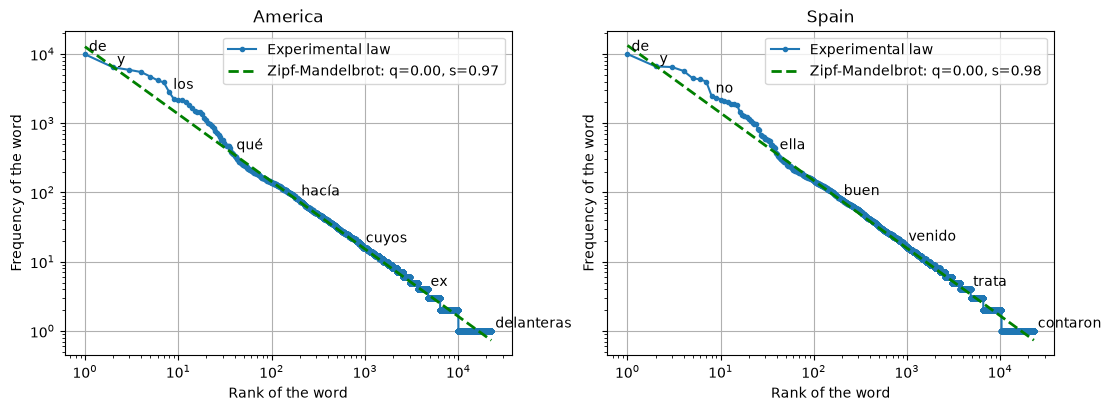

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, layout="constrained")
for ax, (side, side_words) in zip(axes, words.items(), strict=True):
    zipf(Counter(side_words), num_labels=8, show_fit=True, ax=ax, labels={"title": side})
plt.show()

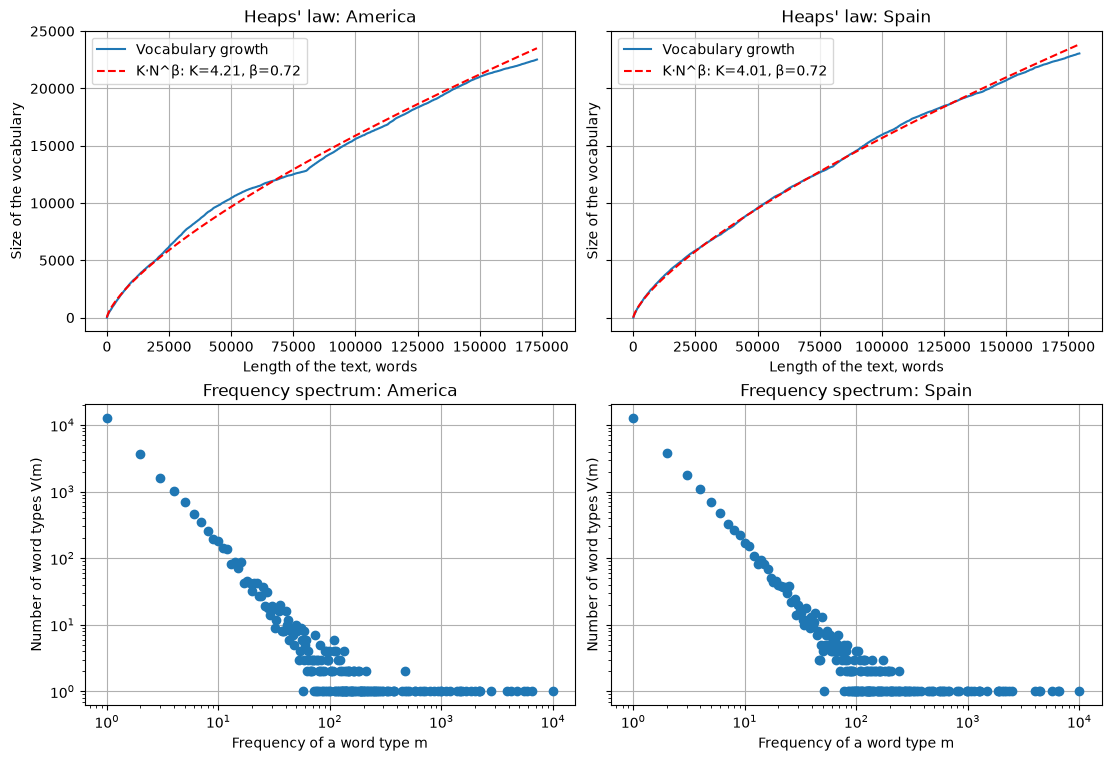

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex="row", sharey="row", layout="constrained")
for column, (side, side_words) in enumerate(words.items()):
    heaps_plot(side_words, ax=axes[0, column], labels={"title": f"Heaps' law: {side}"})
    frequency_spectrum_plot(
        side_words, ax=axes[1, column], labels={"title": f"Frequency spectrum: {side}"}
    )
plt.show()

The two sides have almost the same shape of vocabulary: 22,520 and 23,050 word types, of which 12,542 and 12,700 hapaxes (55.7% and 55.1%), Heaps' exponents β of 0.715 and 0.718, and Zipf exponents s of 0.975 and 0.976 with q = 0, so the Zipf-Mandelbrot fit reduces to Zipf's law with an exponent just under one (R² 0.966 and 0.967). On both Zipf plots the head of the curve, up to about rank 30, bulges above the fitted line, and the rest follows it down to the hapaxes. The American growth curve is less even - it bends where one work gives way to the next - and departs more from its fit (R² 0.995 against 0.999). The frequency spectra have the same shape: some 12,500 hapaxes, then a steep fall, and above about 50 occurrences most frequencies belong to a single word type. By these laws the two samples are the same kind of text.

## Comparison of the corpora

[`compare_corpora`](https://sergeyshk.github.io/esTS/corpus/compare/) splits the texts into windows of 1000 words, computes 132 features of every window - the basic, readability and diversity statistics, the morphology by `es_core_news_sm`, the rhythm of the sentences and the punctuation - and compares the two sides feature by feature: the medians, the 95% bootstrap interval of their difference, Cohen's d, Cliff's delta (|δ| below 0.147 negligible, below 0.33 small, below 0.474 medium, large above), the AUC and the Mann-Whitney test with Holm's correction. To keep the run short, each work gives its first 4000 words, about four windows.

In [24]:
openings = {
    side: [first_words(record["sample"], 4000) for record in records]
    for side, records in sides.items()
}
comparison = compare_corpora(
    openings["America"], openings["Spain"], window=1000, labels=("America", "Spain"), seed=0
)
counts = comparison.iloc[0][["n_America", "n_Spain", "n_texts_America", "n_texts_Spain"]]
print({key: int(value) for key, value in counts.items()})
significant = (comparison["p_holm"] < 0.05).sum()
excluding_zero = ((comparison["ci_low"] > 0) | (comparison["ci_high"] < 0)).sum()
print(f"p_holm < 0.05: {significant} features; bootstrap interval without zero: {excluding_zero}")
columns = [
    "median_America",
    "median_Spain",
    "ci_low",
    "ci_high",
    "cliff_delta",
    "auc",
    "p_value",
    "p_holm",
]
comparison[columns].head(12).round(3)

{'n_America': 36, 'n_Spain': 36, 'n_texts_America': 9, 'n_texts_Spain': 9}
p_holm < 0.05: 0 features; bootstrap interval without zero: 1


,median_America,median_Spain,ci_low,ci_high,cliff_delta,auc,p_value,p_holm
morph_definite_Def,0.814,0.858,-0.081,0.021,-0.340,0.330,0.013,1.0
morph_definite_Ind,0.186,0.142,-0.020,0.081,0.340,0.670,0.013,1.0
morph_pron_type_Tot,0.017,0.024,-0.012,-0.003,-0.309,0.345,0.024,1.0
punct_comma,91.937,83.456,-8.089,25.698,0.293,0.647,0.033,1.0
morph_pos_NOUN,0.218,0.201,-0.008,0.033,0.286,0.643,0.037,1.0
morph_mood_Sub,0.066,0.080,-0.034,0.006,-0.269,0.365,0.050,1.0
morph_gender_Fem,0.415,0.438,-0.056,0.017,-0.258,0.371,0.061,1.0
morph_gender_Masc,0.585,0.562,-0.021,0.057,0.258,0.629,0.061,1.0
morph_pron_type_Art,0.494,0.466,-0.041,0.119,0.252,0.626,0.067,1.0
morph_pron_type_Prs,0.270,0.307,-0.090,0.023,-0.249,0.375,0.070,1.0


By the features of the text the two sides hardly differ. With 36 windows of nine works on each side no feature has a `p_holm` below 0.05, and only one bootstrap interval, which resamples whole works, excludes zero: `morph_pron_type_Tot`, the pronouns and determiners of totality such as *todo* (median 0.017 against 0.024, interval from −0.012 to −0.003, δ = −0.31, a small effect). The largest effect, |δ| = 0.34 (medium), is the share of the definite article among the articles (0.814 against 0.858), with an interval from −0.081 to 0.021; the American windows have more commas per 1000 words (91.9 against 83.5, δ = 0.29) and more nouns (δ = 0.29), the Spanish ones more subjunctives (δ = −0.27), all with intervals across zero. As the page of the comparison warns, the windows of one work are not independent, so even these p-values are too small, and with nine works a side the intervals are rough. What sets the two sides apart lies in the words, not in these statistics.

## Summary

- The samples are balanced by genre, period and size - nine works and about 175,000 words a side - but not by author: three of the American works are Payró's.
- The keywords of one corpus against the other are first of all names. Without names and words of a single author, America keeps the words of its themes (`rey`, `oro`, `pueblo`, `gobierno`) and `pesos`, Spain the address (`tú`, `usted`, `os`) and words of art.
- The regional forms need the dispersion and the concordance: `sos`, `misia` and `comisario` are American keywords of one author (DP 0.70 to 0.77), and `vos` is no keyword because the form covers the voseo of Payró, the reverential address of Valle-Inclán and the popular `os` in Galdós.
- Money is the lexical difference that holds in the collocations and the concordance: `peso` goes with `mil`, `pagar` and `cobrar` in America, and `plata` is money in Payró and the metal elsewhere.
- Against the frequency dictionary both sides show the register of fiction (`yo`, `mi`, `don`, `aquel`, `oh`), not a country.
- Zipf's and Heaps' laws give the same exponents on both sides (s 0.975 and 0.976, β 0.715 and 0.718), and `compare_corpora` finds no feature that separates them: the largest |δ| is 0.34, and nothing is significant after Holm's correction.